In [37]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Took help of LLM to check which libraries needed to be imported
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error

In [ ]:
# Load Data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test_features.csv')

# EDA

In [39]:
### 0: Framing
print("Framing:")
print("This is a supervised learning problem.")
print("The target column is price.")
print("The target is numeric, so this is a regression problem.")

Framing:
This is a supervised learning problem.
The target column is price.
The target is numeric, so this is a regression problem.


This is a supervised learning problem because the training dataset includes a known target value. Each row represents one Airbnb listing, and the model uses the listing features to predict the target column.
The target column is price. Since price is a numeric value, this is a regression problem. It is not a classification problem because the model is not predicting a category. It is predicting a dollar amount.
This is also not mainly an unsupervised learning problem because there is a clear target variable. Unsupervised methods could be used for exploration, but the main task is supervised regression.

In [40]:
### 1: Data Quality
print("Data Quality:")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

print("\nColumns only in training set:")
print(sorted(train_cols - test_cols))

print("\nColumns only in test set:")
print(sorted(test_cols - train_cols))

print("\nNumber of matching columns:")
print(len(train_cols & test_cols))

train_missing = train_df.isna().sum()
test_missing = test_df.isna().sum()

print("\nColumns with missing values in training set:")
print(train_missing[train_missing > 0].sort_values(ascending=False))

print("\nColumns with missing values in test set:")
print(test_missing[test_missing > 0].sort_values(ascending=False))

print("\nRows in training set:", len(train_df))
print("Rows in test set:", len(test_df))

# Columns with no missing values
train_usable_cols = train_df.columns[train_df.isna().sum() == 0]
test_usable_cols = test_df.columns[test_df.isna().sum() == 0]

# Feature columns only means exclude the target column, price
train_feature_cols = train_df.drop(columns=["price"]).columns

train_usable_feature_cols = [
    col for col in train_feature_cols
    if train_df[col].isna().sum() == 0
]

test_usable_feature_cols = [
    col for col in test_df.columns
    if test_df[col].isna().sum() == 0
]

common_cols = sorted(set(train_feature_cols) & set(test_df.columns))

# These are the shared feature columns that have no missing values in either dataset.
usable_common_feature_cols = [
    col for col in common_cols
    if train_df[col].isna().sum() == 0 and test_df[col].isna().sum() == 0
]

print("\nTotal columns usable as-is in training set:", len(train_usable_cols))
print(list(train_usable_cols))

print("\nFeature columns usable as-is in training set:", len(train_usable_feature_cols))
print(train_usable_feature_cols)

print("\nFeature columns usable as-is in test set:", len(test_usable_feature_cols))
print(test_usable_feature_cols)

print("\nMatching feature columns usable as-is in both train and test:", len(usable_common_feature_cols))
print(usable_common_feature_cols)

Data Quality:
Training shape: (42234, 36)
Test shape: (8199, 35)

Columns only in training set:
['price']

Columns only in test set:
[]

Number of matching columns:
35

Columns with missing values in training set:
license                        42234
neighbourhood_group            42234
review_scores_value             9137
review_scores_location          9137
review_scores_checkin           9137
review_scores_communication     9136
review_scores_cleanliness       9136
review_scores_accuracy          9136
reviews_per_month               9135
last_review                     9135
review_scores_rating            9135
beds                              80
bedrooms                          47
bathrooms                         42
host_name                         18
host_total_listings_count         16
host_identity_verified            16
host_has_profile_pic              16
dtype: int64

Columns with missing values in test set:
neighbourhood_group    8199
license                8199
dtype: in

The training set has 42,234 rows and 36 columns. The test set has 8,199 rows and 35 columns. The only column that appears in the training set but not in the test set is price. This makes sense because price is the target column that the model is trying to predict.

There are 35 matching columns between the training and test sets. These matching columns are the feature columns that can be used to train the model and later generate predictions for the test set.

There are missing values in several columns in the training set. The largest missing-value columns are license and neighbourhood_group, which are completely missing. Several review score columns and last_review also have many missing values. The test set has missing values only in neighbourhood_group and license.

There are 18 total columns in the training set with no missing values, but one of those is price, which is the target. Therefore, 17 training feature columns are usable as-is. The test set has 33 feature columns usable as-is. There are 17 matching feature columns usable as-is in both the training and test sets.

For modeling, I will not simply drop every row with missing values because that would remove useful data. Instead, I will handle missing numeric values with median imputation and missing categorical values with most-frequent imputation. I will also drop columns that are identifiers, free-text, or mostly/completely missing when they are not useful for prediction.

Distributions:


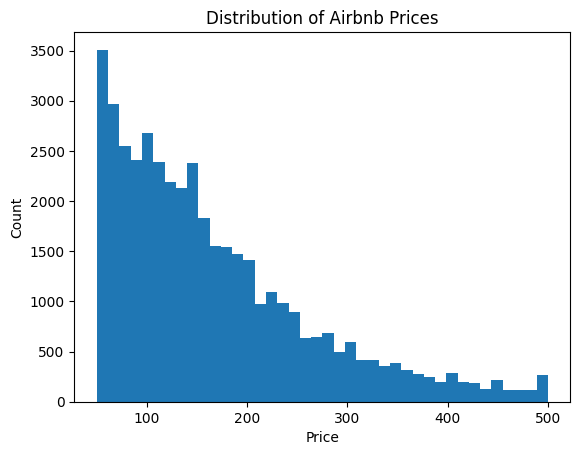

Median price: 141.0
Mean price: 166.24274281384666
Price skew: 1.180650665854797


,column,unique_values
0,name,41118
1,host_name,9091
2,host_has_profile_pic,2
3,host_identity_verified,2
4,neighbourhood,33
5,room_type,4
6,amenities,38642
7,last_review,1660


In [41]:
### 2: Distributions
print("Distributions:")

# Plot the target distribution to check whether price looks normally distributed.
plt.hist(train_df["price"], bins=40)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Airbnb Prices")
plt.show()

print("Median price:", train_df["price"].median())
print("Mean price:", train_df["price"].mean())
print("Price skew:", train_df["price"].skew())

# Count unique values in text columns to decide which columns can be encoded.
categorical_cols = train_df.select_dtypes(include=["object", "string"]).columns

unique_values = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [train_df[col].nunique() for col in categorical_cols]
})

unique_values

The price distribution is not normally distributed. The histogram shows that most listings are at lower prices, while fewer listings have much higher prices. This creates a right-skewed distribution.

The median price is 141.0, while the mean price is about 166.25. Since the mean is higher than the median, that also supports that the distribution is right-skewed. The skew value is about 1.18, which means the price column has a noticeable positive skew.

The non-numeric columns have different numbers of unique values. Some columns are reasonable to encode directly, such as room_type with 4 unique values, host_has_profile_pic with 2, host_identity_verified with 2, and neighbourhood with 33. Other columns have too many unique values to use directly, such as name, host_name, amenities, and last_review.

For the model, I will one-hot encode useful categorical columns like room_type and neighbourhood. I will drop messy text columns such as name and host_name. I will also convert amenities into a simpler numeric feature, such as amenities_count, instead of using the raw text directly.

# Data cleansing / Feature Engineering

In [42]:
def prepare_features(train_df, test_df):
    train = train_df.copy()
    test = test_df.copy()

    all_dates = pd.concat([
        train["last_review"],
        test["last_review"]
    ])

    all_dates = pd.to_datetime(all_dates, errors="coerce")
    reference_date = all_dates.max()

    # Done using LLM
    for df in [train, test]:
        # Convert the raw amenities text into a count of listed amenities.
        df["amenities_count"] = df["amenities"].fillna("").apply(
            lambda x: 0 if x in ["", "[]"] else len(str(x).split(","))
        )
        # Convert last_review into the number of days since the last review.
        df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")
        df["days_since_last_review"] = (
            reference_date - df["last_review"]
        ).dt.days

        # Drop identifiers, raw text fields, and columns that are not useful directly.
        drop_cols = [
            "id",
            "host_id",
            "name",
            "host_name",
            "license",
            "neighbourhood_group",
            "amenities",
            "last_review"
        ]

        df.drop(columns=drop_cols, inplace=True)

    return train, test

In [43]:
train_clean, test_clean = prepare_features(train_df, test_df)

# Separate the input features from the target column.
X = train_clean.drop(columns=["price"])
y = train_clean["price"]

# Keep the cleaned test features for the final prediction step.
X_test_final = test_clean.copy()

# Model preparation

In [44]:
# Select numeric and categorical columns so each type can be processed correctly.
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

# Fill missing numeric values with the median and scale them.
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Done using LLM
categorical_transformer = Pipeline([ # Fill missing categorical values and one-hot encode text categories.
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the correct preprocessing steps to each column type.
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_cols),
    ("categorical", categorical_transformer, categorical_cols)
])

In [45]:
# Split the training data so model performance can be checked before using the real test set.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model

In [46]:
# Build a Linear Regression model with the same preprocessing steps.
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Log-transform price because the EDA showed that price is right-skewed.
linear_model = TransformedTargetRegressor(
    regressor=linear_model,
    func=np.log1p,
    inverse_func=np.expm1
)

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_valid)
linear_preds = np.clip(linear_preds, 50, 500)

# Evaluate the model using RMSE on the validation set.
linear_rmse = root_mean_squared_error(y_valid, linear_preds)

print("Linear Regression RMSE:", linear_rmse)

Linear Regression RMSE: 66.8489153905572


In [47]:
# Build a CART Decision Tree model with controlled depth to reduce overfitting.
cart_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=16,
        min_samples_leaf=50,
        random_state=42
    ))
])

# Use the same log target transformation so this model is comparable to Linear Regression.
cart_model = TransformedTargetRegressor(
    regressor=cart_model,
    func=np.log1p,
    inverse_func=np.expm1
)

cart_model.fit(X_train, y_train)

cart_preds = cart_model.predict(X_valid)
cart_preds = np.clip(cart_preds, 50, 500)

# Evaluate the model using RMSE on the validation set.
cart_rmse = root_mean_squared_error(y_valid, cart_preds)

print("CART Decision Tree RMSE:", cart_rmse)

CART Decision Tree RMSE: 63.84984919061986


In [48]:
# Compare validation RMSE for the models that were tried.
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "CART Decision Tree"
    ],
    "Validation RMSE": [
        linear_rmse,
        cart_rmse
    ]
})

results

,Model,Validation RMSE
0,Linear Regression,66.848915
1,CART Decision Tree,63.849849


In [49]:
# Done using LLM
final_model = Pipeline([ # Train the selected final model on the full training dataset.
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=16,
        min_samples_leaf=50,
        random_state=42
    ))
])

final_model = TransformedTargetRegressor(
    regressor=final_model,
    func=np.log1p,
    inverse_func=np.expm1
)

final_model.fit(X, y)

# Generate predictions for every row in the test feature file.
final_predictions = final_model.predict(X_test_final)

# Keep predictions within the observed training price range.
final_predictions = np.clip(final_predictions, 50, 500)

In [ ]:
# Done using LLM
submission = pd.DataFrame({ # Save predictions in the required one-column CSV format.
    "price": final_predictions
})

submission.to_csv("predictons.csv", index=False)

submission.head()

,price
0,223.450064
1,115.838204
2,199.171460
3,215.635674
4,264.923771


The final model I used was a CART Decision Tree Regressor (The RMSE for Linear Regression was too high). I used median imputation for missing numeric values, most-frequent imputation for missing categorical values, and one-hot encoding for categorical variables. I dropped identifier columns and messy free-text columns because they do not generalize well to the test set. I also created two simple features: amenities_count and days_since_last_review. Since price is right-skewed, I trained the model on log-transformed prices and converted predictions back to dollars. The final predictions were clipped between 50 and 500 because the training prices are within that range.

In [52]:
# Check that the submission has one prediction per test row and no missing values.
print("Submission shape:", submission.shape)
print("Test rows:", len(test_df))
print("Missing predictions:", submission["price"].isna().sum())
print("Columns:", submission.columns.tolist())

submission.describe()

Submission shape: (8199, 1)
Test rows: 8199
Missing predictions: 0
Columns: ['price']


,price
count,8199.000000
mean,156.075865
std,75.120467
min,56.173500
25%,95.834611
50%,140.345794
75%,200.004625
max,414.629451


LLM Use
1. I used ChatGPT
2. I asked prompts regarding what libraries needed to be imported, some help in areas in feature engineering and model preparation and towards the end of the assignment where we had to submit the prices into a csv file.
3. Yes it was useful. I wouldn't have known about each library that needed to be added and I was stuck on those areas for those code snippets during prep. I have also not really ever exported python output to other places like csv files so that was helpful as well.
4. I learned about those key snippets that were needed. This is not really related, but another way I realized to learn about the libraries could have been attempting to code this in Google Colab instead of Jupyter Notebook as its in-built Gemini would help in grasping some of the libraries needed. 